In [1]:
import pandas as pd 

df = pd.read_csv("../data/cville_weather_cleaned.csv")
df_v2 = df.copy()

In [2]:
df_v2 = df.drop(columns=["state", "next_state", "next_2_states", "next_week", "next_2_weeks"])

In [3]:
df_v2.head()

,STATION,DATE,NAME,PRCP,SNOW,SNWD,TMAX,TMIN,WT01,WT03,WT04,WT05,WT06,WT08,WT11,WT14,WT16,WT18,season
0,USC00441593,2000-01-01,"CHARLOTTESVILLE 2 W, VA US",0.0,0.0,0.0,62.1,37.0,0,0,0,0,0,0,0,0,0,0,Winter
1,USC00441593,2000-01-02,"CHARLOTTESVILLE 2 W, VA US",0.0,0.0,0.0,55.9,53.1,0,0,0,0,0,0,0,0,0,0,Winter
2,USC00441593,2000-01-03,"CHARLOTTESVILLE 2 W, VA US",0.0,0.0,0.0,60.1,51.1,0,0,0,0,0,0,0,0,0,0,Winter
3,USC00441593,2000-01-04,"CHARLOTTESVILLE 2 W, VA US",0.0,0.0,0.0,69.1,54.0,0,0,0,0,0,0,0,0,0,0,Winter
4,USC00441593,2000-01-05,"CHARLOTTESVILLE 2 W, VA US",86.0,0.0,0.0,68.0,33.1,0,0,0,0,0,0,0,0,0,0,Winter


In [4]:
def get_precip(row):
    if row["PRCP"] == 0:
        return "Dry"
    elif row["PRCP"] <= 2:
        return "Light"
    elif row["PRCP"] <= 10:
        return "Moderate"
    else:
        return "Heavy"


def get_temp(row):
    if row["TMAX"] > 83:
        return "Hot"
    elif row["TMIN"] < 54:
        return "Cold"
    else:
        return "Mild"

def get_severe(row):
    if row["WT06"] == 1:
        return "Ice"
    elif row["WT04"] == 1:
        return "FrozenMix"   
    elif row["WT18"] == 1:
        return "Snow"
    elif row["WT03"] == 1:
        return "Thunder"
    elif row["WT05"] == 1:
        return "Hail"
    elif row["WT11"] == 1:
        return "Wind"
    elif row["WT01"] == 1:
        return "Fog"
    else:
        return "None"

def collapse_severe(s):
    if s in ["Ice", "FrozenMix", "Snow"]:
        return "WinterStorm"
    elif s in ["Thunder", "Hail"]:
        return "ConvectiveStorm"
    elif s == "Wind":
        return "Wind"
    elif s == "Fog":
        return "Fog"
    else:
        return "None"

def classify_weather(row):
    precip = get_precip(row)
    temp = get_temp(row)
    severe_raw = get_severe(row)
    severe = collapse_severe(severe_raw)

    if precip == "Dry":
        return f"Dry-{temp}-{severe}"

    if precip in ["Light", "Moderate"]:
        if severe == "None":
            return f"{precip}-{temp}-None"
        else:
            return f"{precip}-{temp}-{severe}"

    if precip == "Heavy":
        if severe == "None":
            return f"Heavy-{temp}-None"
        elif severe in ["WinterStorm", "ConvectiveStorm"]:
            return f"Heavy-{temp}-{severe}"
        else:
            return f"Heavy-Mild-{severe}"


df_v2["state"] = df_v2.apply(classify_weather, axis=1)

In [5]:
df_v2 = df_v2.sort_values("DATE").reset_index(drop=True)
df_v2["state"] = df_v2.apply(classify_weather, axis=1)

In [6]:
df_v2["DATE"] = pd.to_datetime(df_v2["DATE"])

train_df_v2 = df_v2[df_v2["DATE"].dt.year <= 2024].copy()
test_df_v2  = df_v2[df_v2["DATE"].dt.year == 2025].copy()

In [7]:
df_v2["next_state"] = df_v2["state"].shift(-1)
df_v2 = df_v2.dropna(subset=["next_state"])

In [8]:
train_df_v2["next_state"] = train_df_v2["state"].shift(-1)
train_df_v2 = train_df_v2.dropna(subset=["next_state"])

In [9]:
df_v2 = df_v2.dropna(subset=["next_state"])

In [10]:
df_v2.to_csv("../data/cville_weather_cleaned.csv", index=False)

# Transition Probability Matrix Full Dataset 

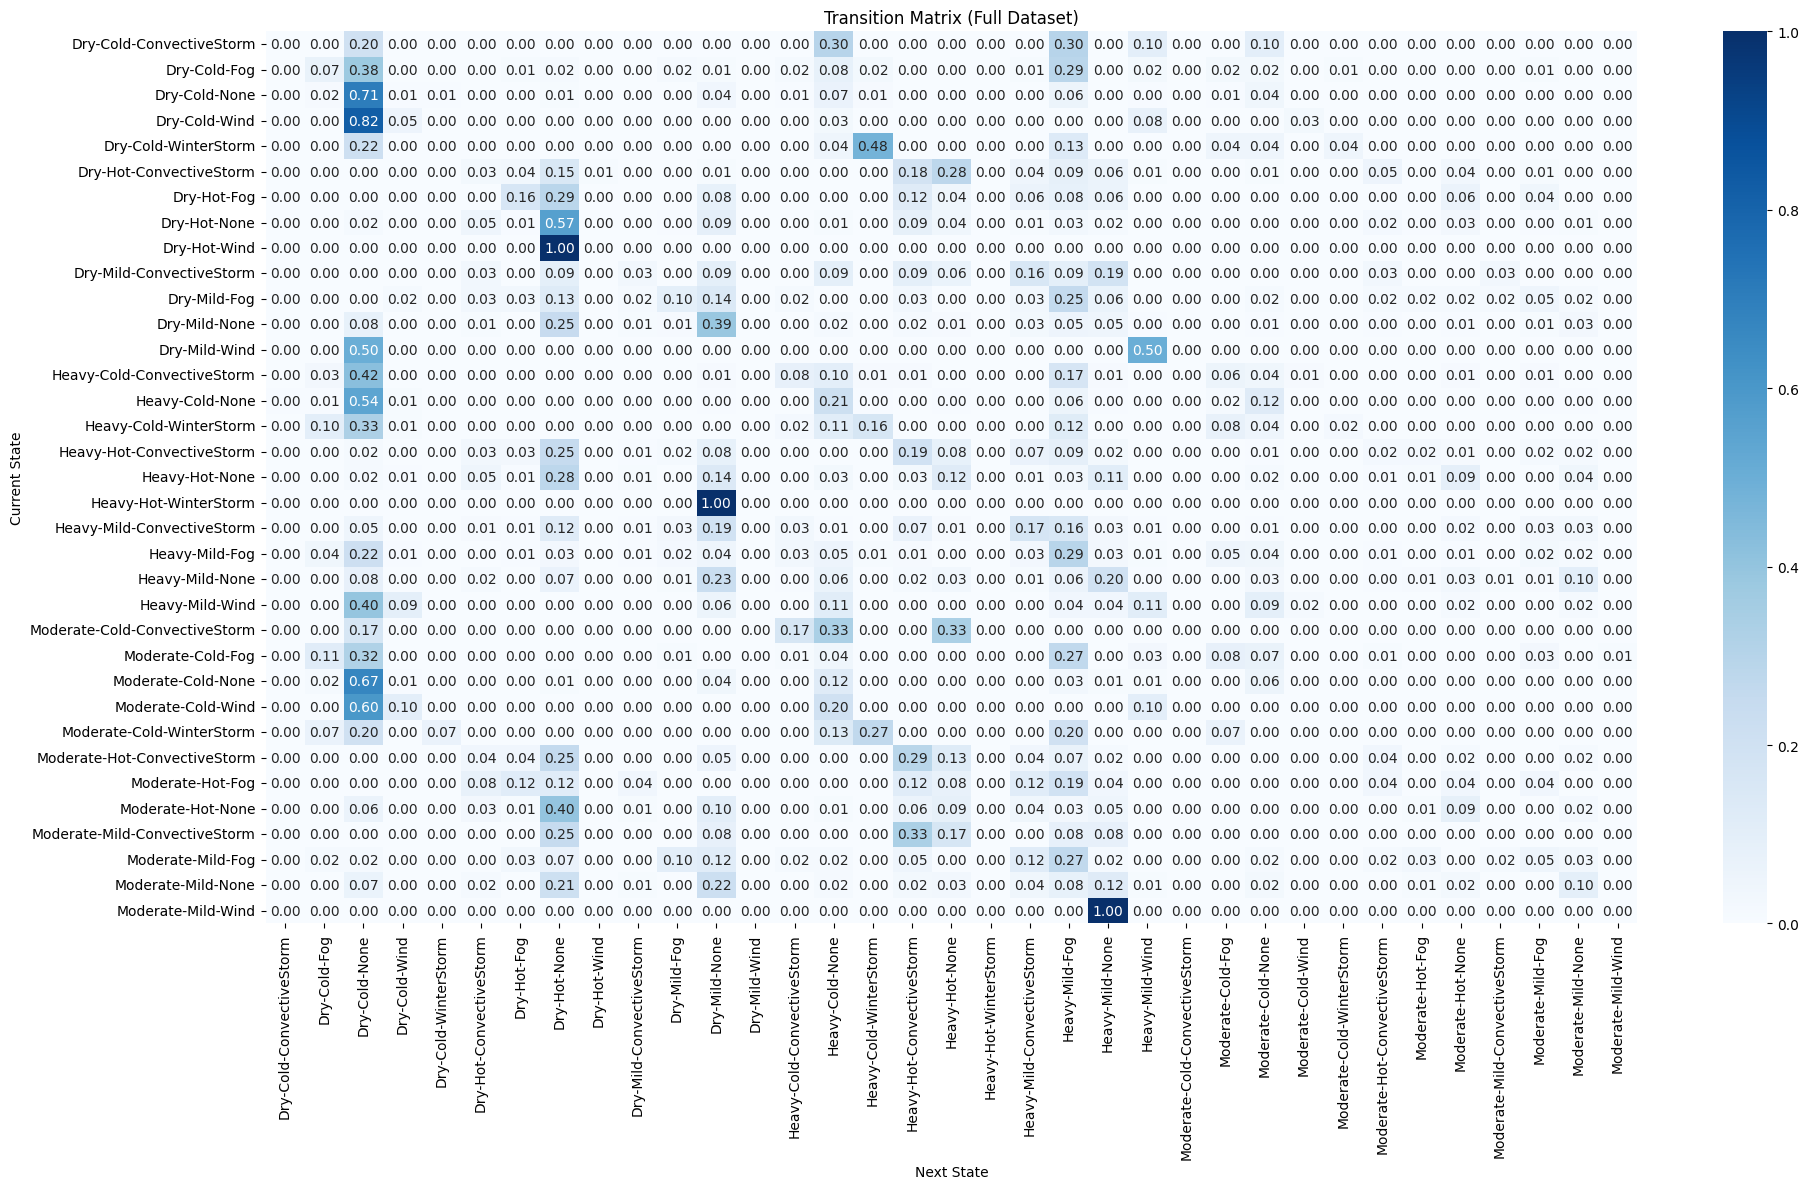

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

full_matrix_v2 = pd.crosstab(
    train_df_v2["state"], 
    train_df_v2["next_state"], 
    normalize="index"
)

states_v2 = sorted(train_df_v2["state"].unique())

full_matrix_v2 = full_matrix_v2.reindex(
    index=states_v2,
    columns=states_v2,
    fill_value=0
)

row_sums_v2 = full_matrix_v2.sum(axis=1)
for state in states_v2:
    if row_sums_v2[state] == 0:
        full_matrix_v2.loc[state, state] = 1.0

plt.figure(figsize=(20, 12))

sns.heatmap(
    full_matrix_v2,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=True
)

plt.title("Transition Matrix (Full Dataset)")
plt.xlabel("Next State")
plt.ylabel("Current State")

plt.tight_layout()
plt.show()

# Transition Matrices Seasonal

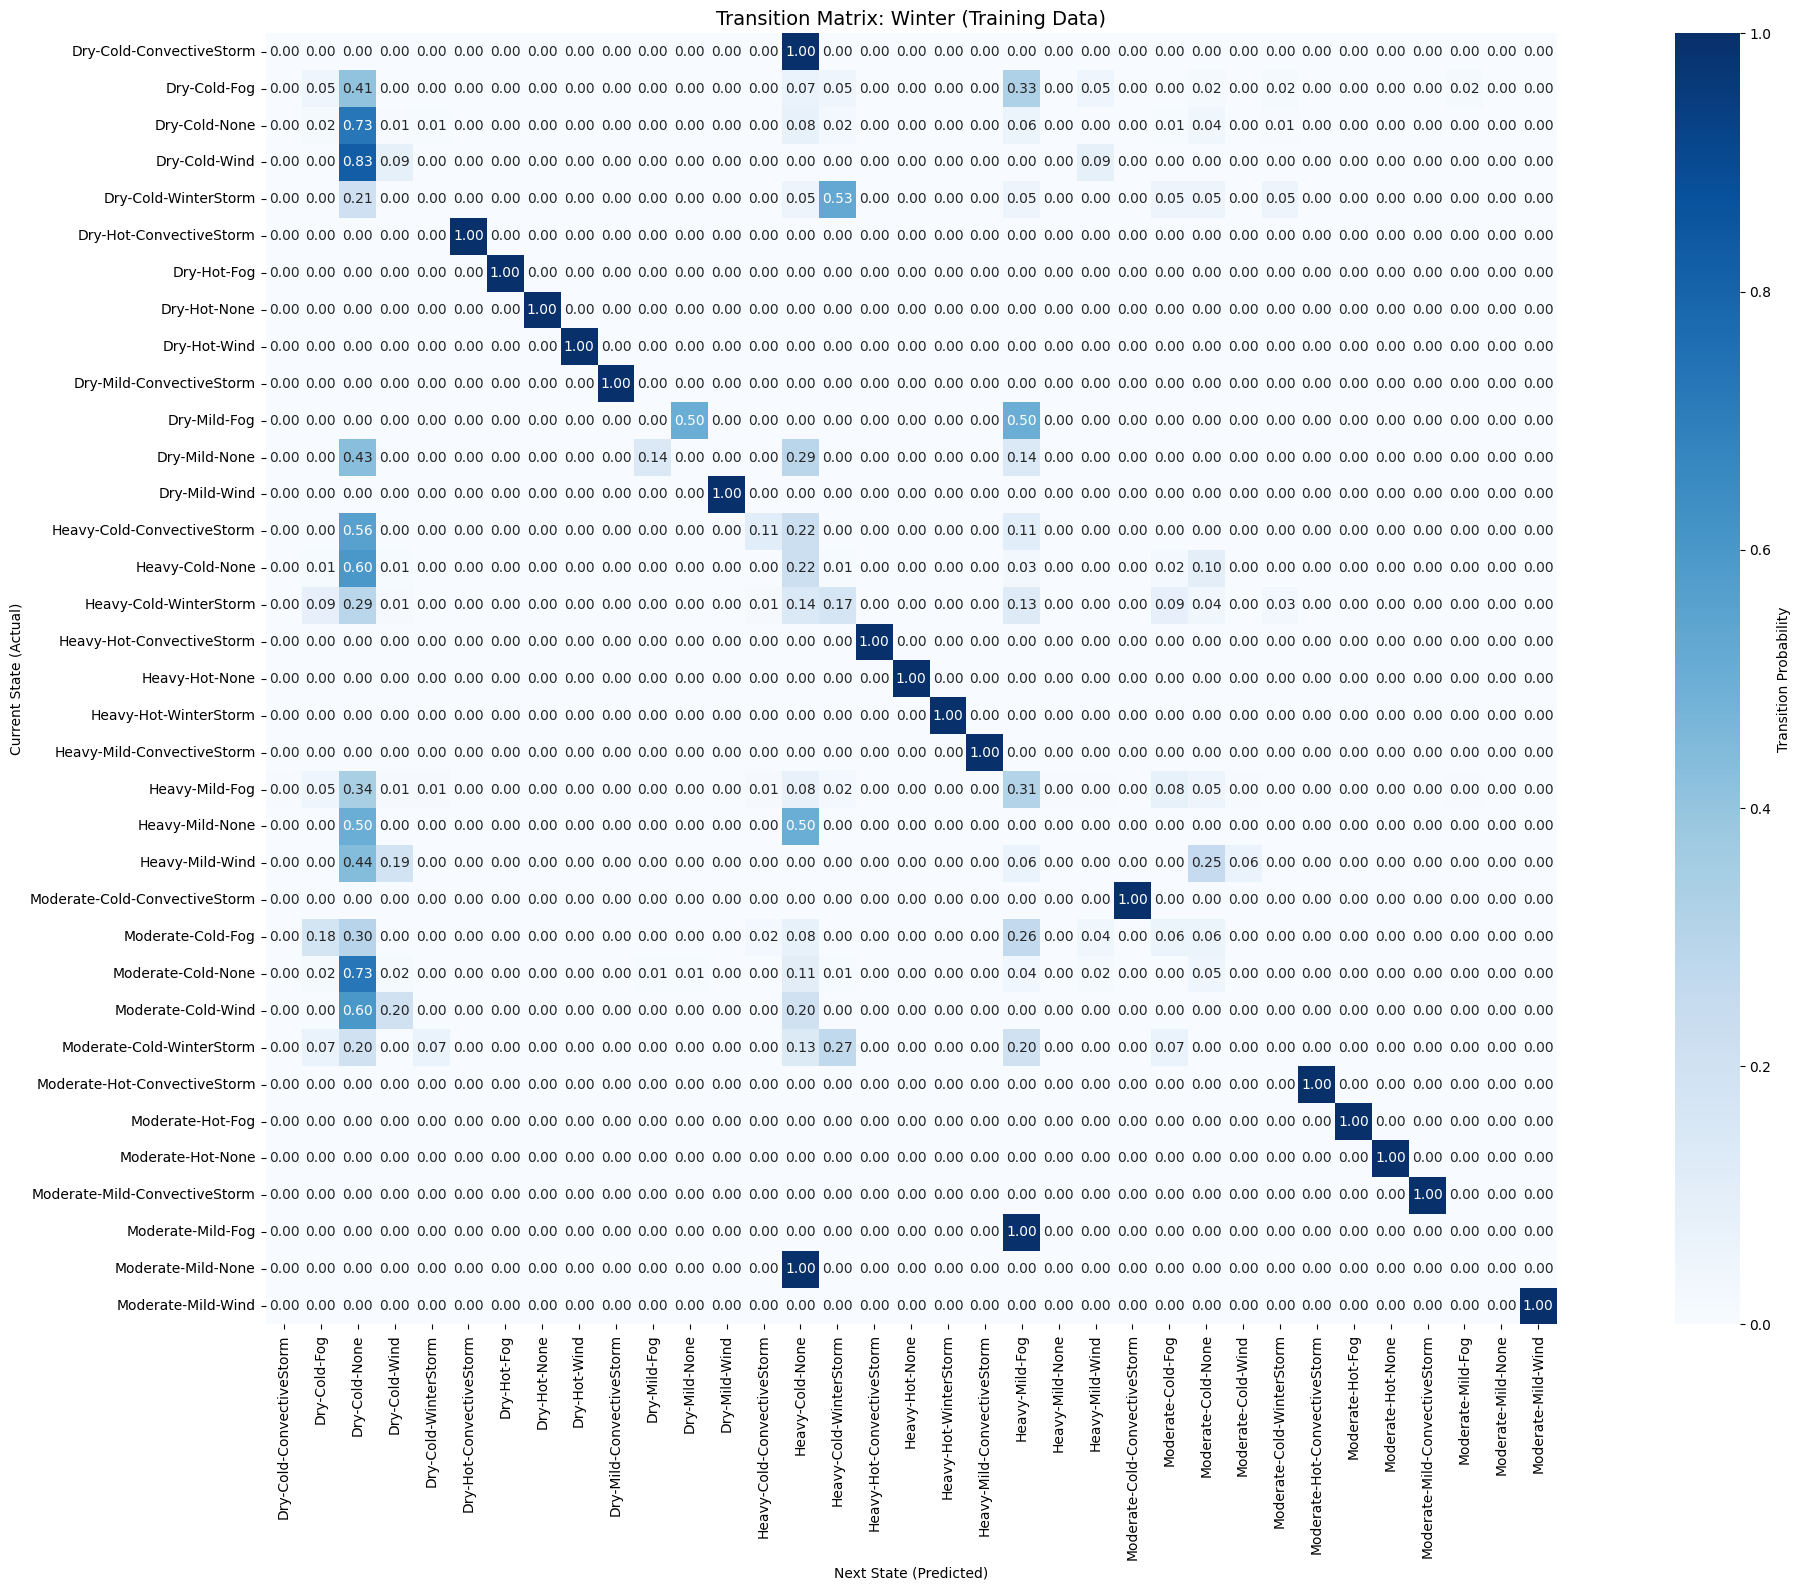

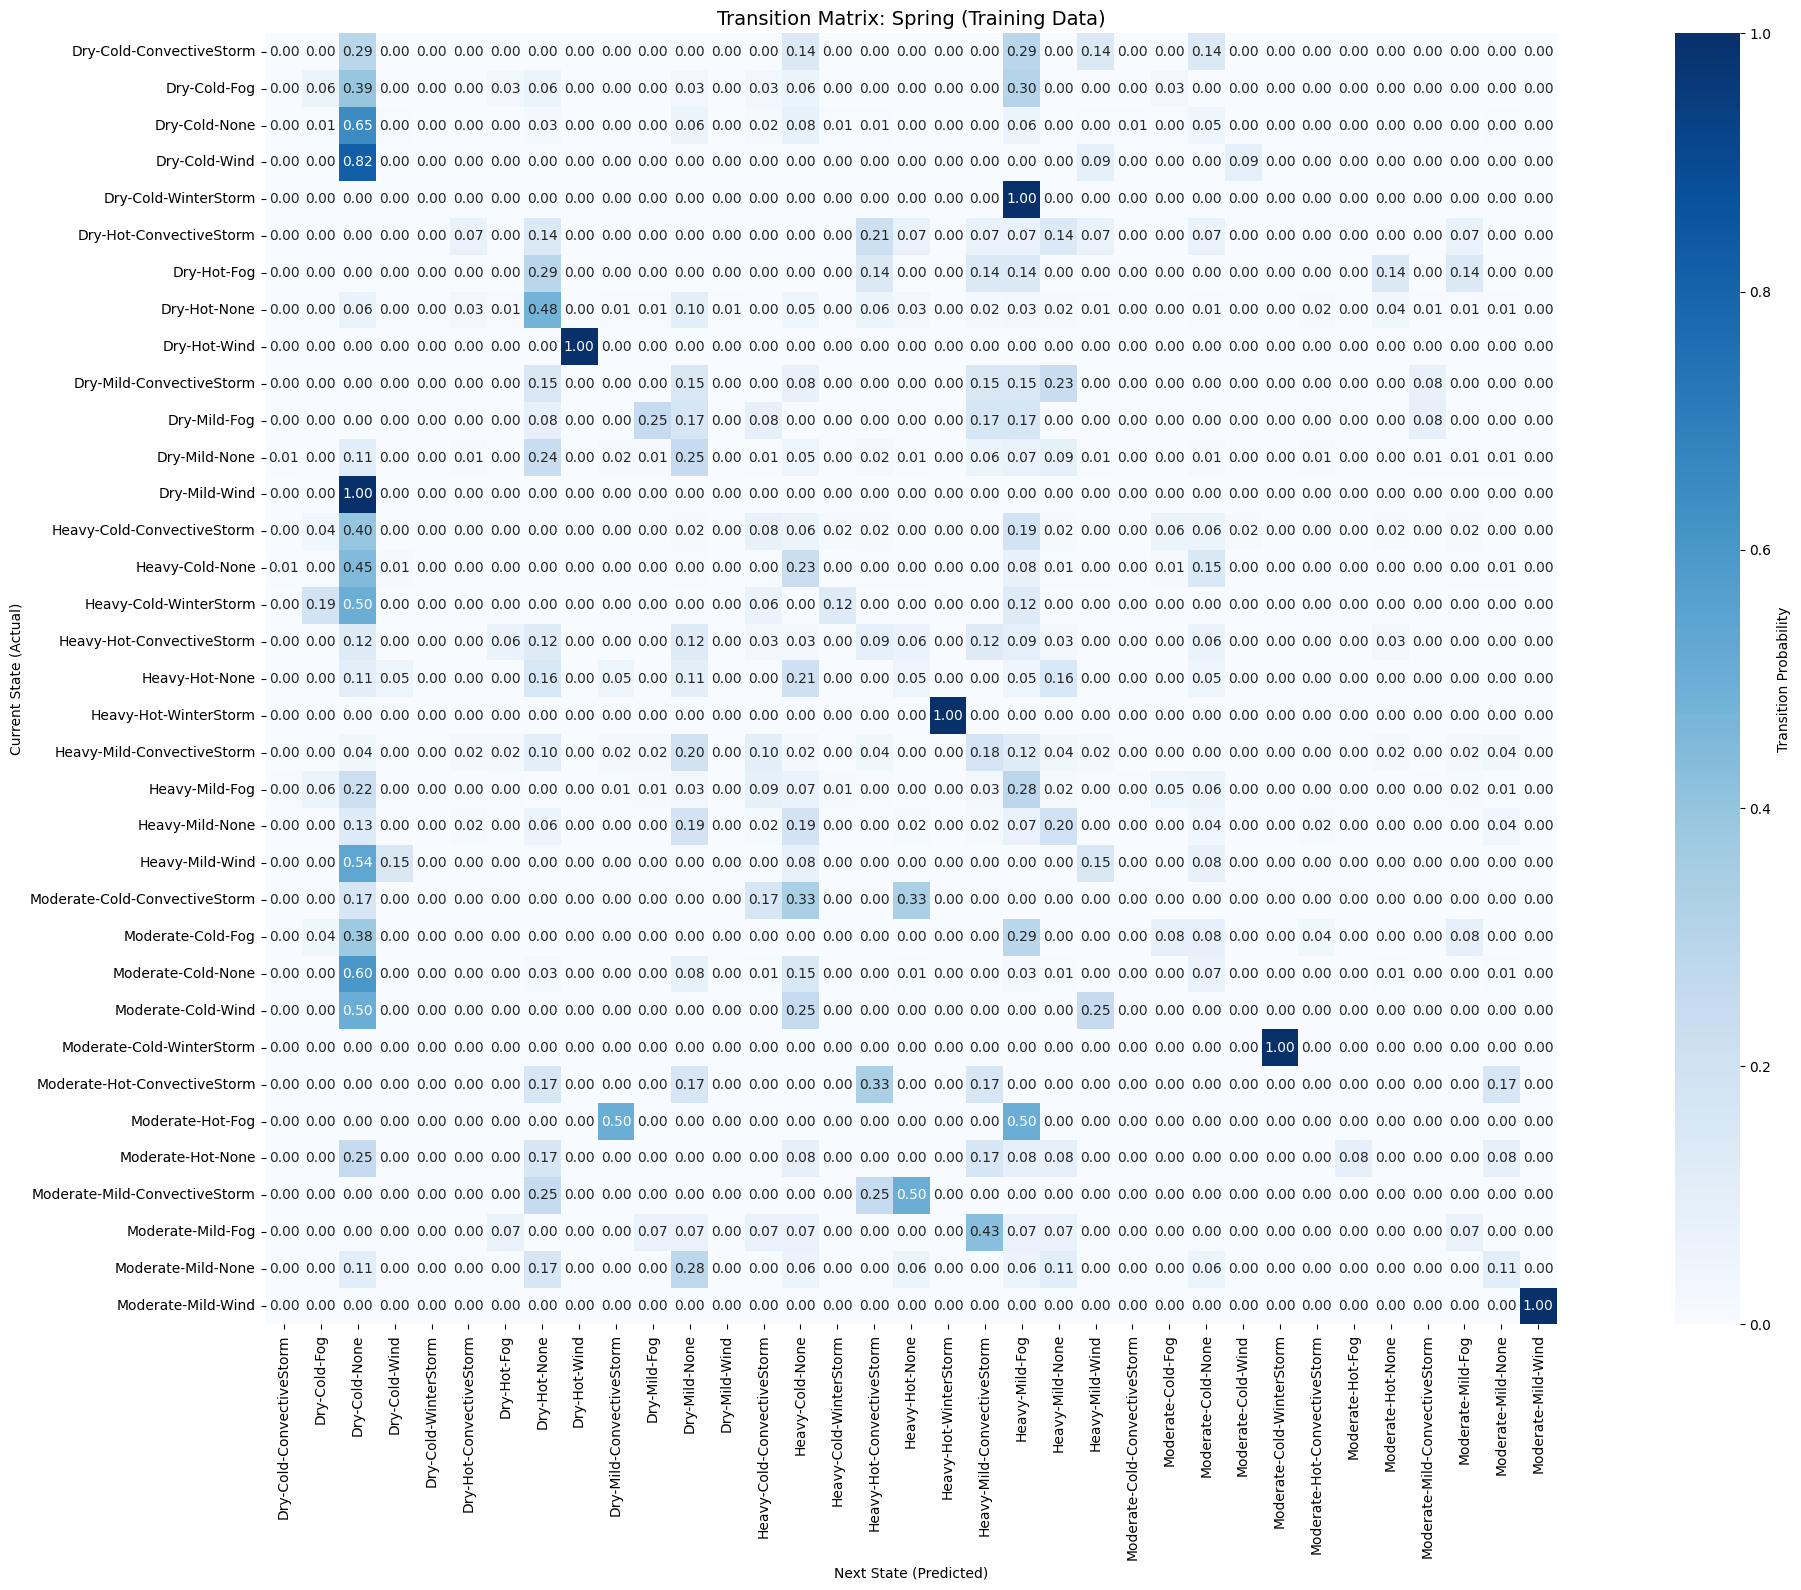

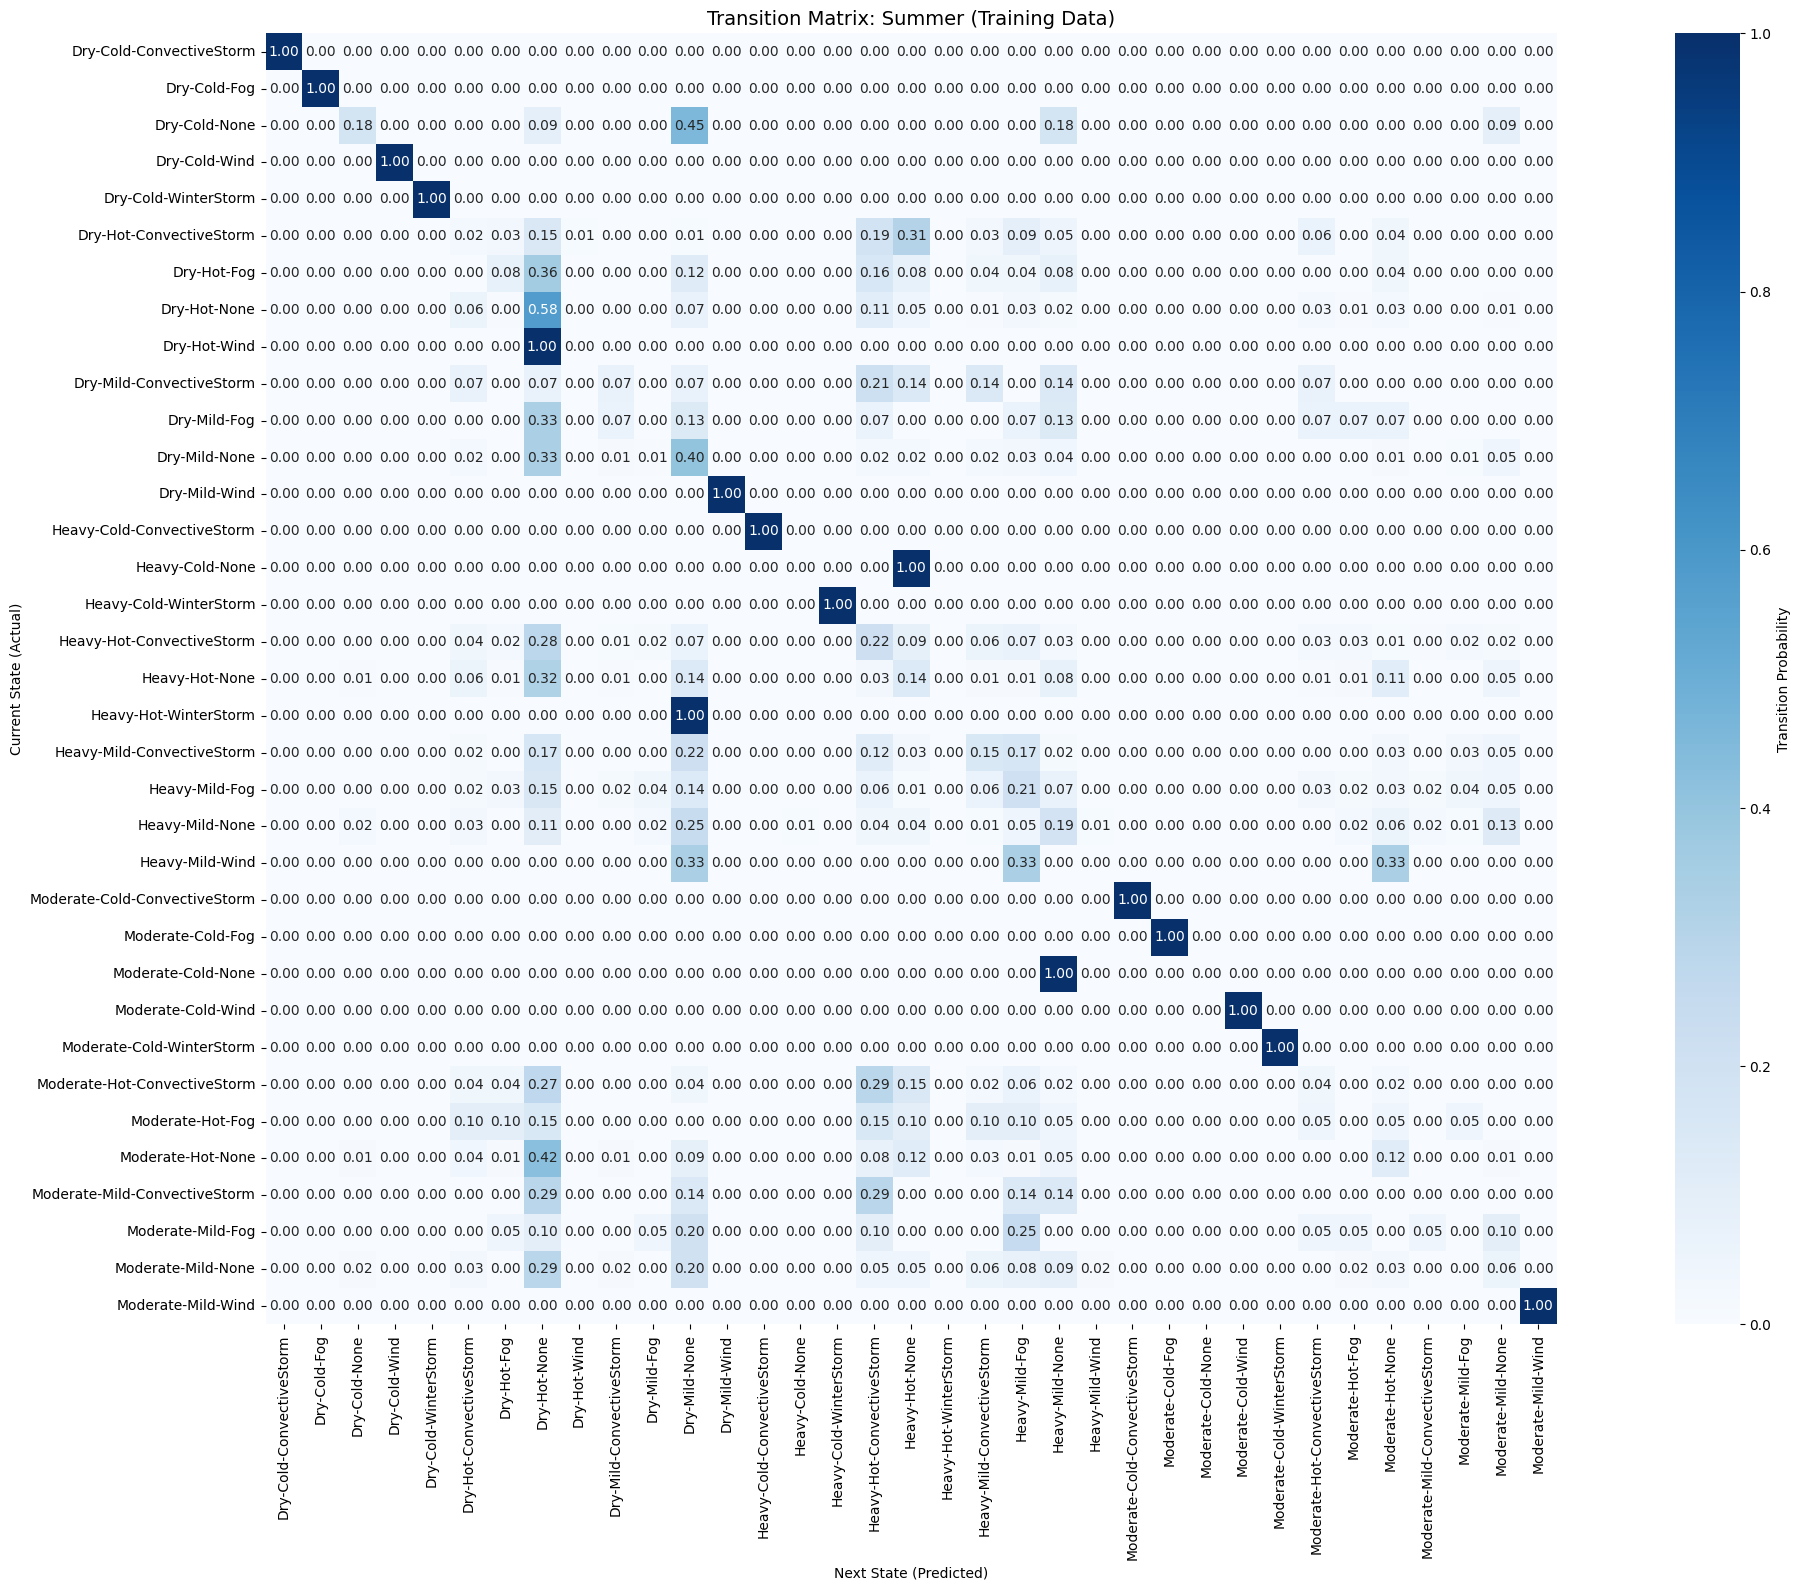

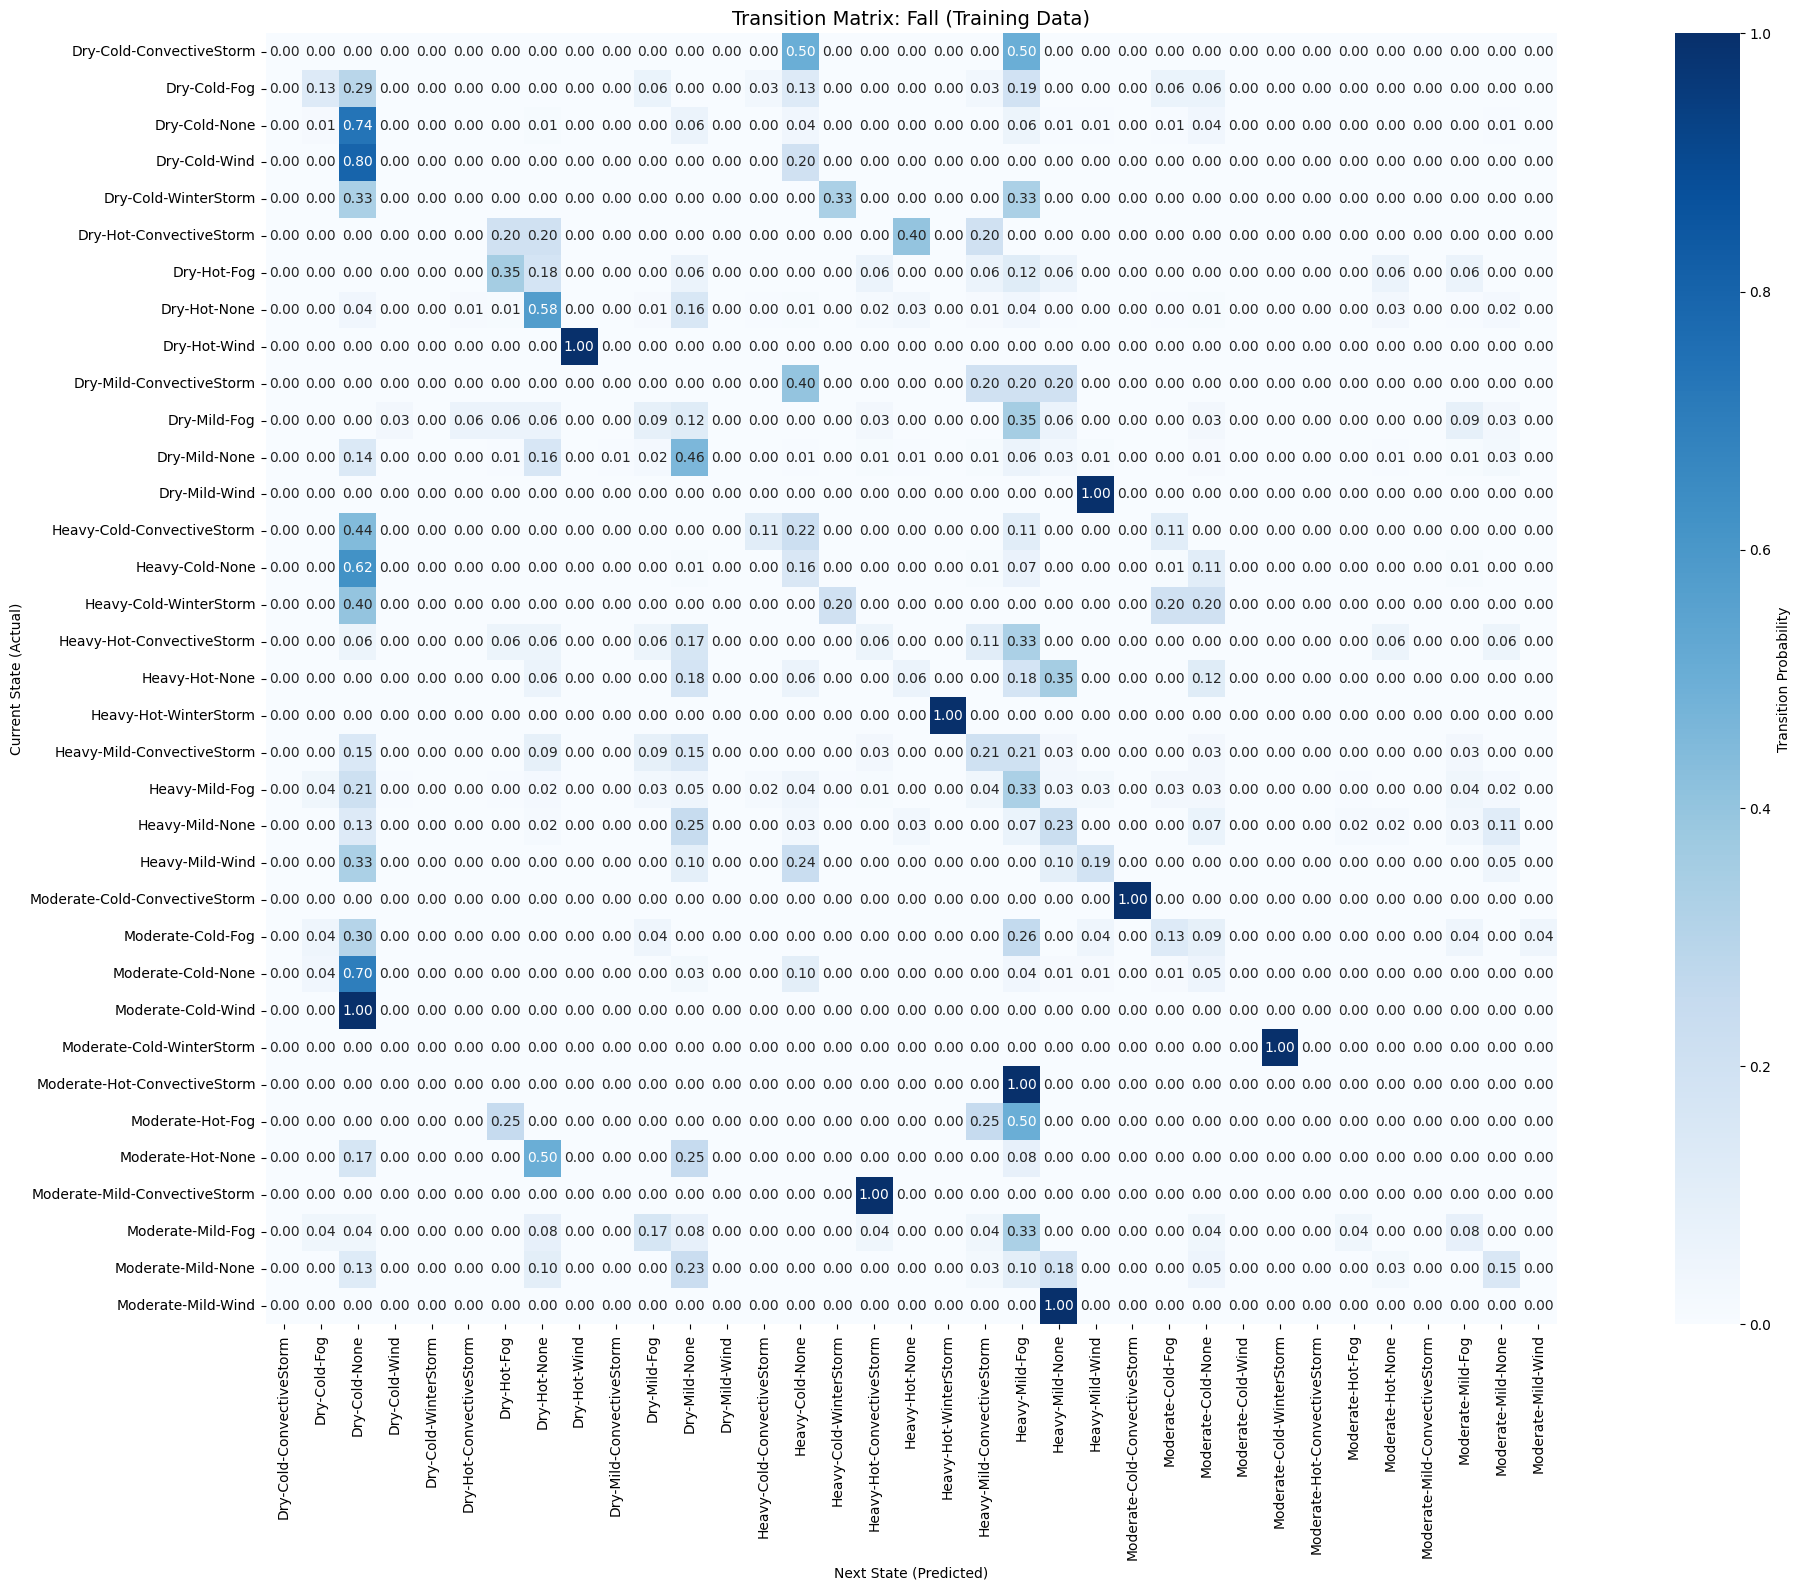

In [12]:
states_v2 = sorted(df_v2["state"].unique())
season_matrices_v2 = {}

for season in train_df_v2["season"].unique():
    season_df_v2 = train_df_v2[train_df_v2["season"] == season]
    
    seasonal_matrix_v2 = pd.crosstab(
        season_df_v2["state"],
        season_df_v2["next_state"],
        normalize="index"
    )
    
    seasonal_matrix_v2 = seasonal_matrix_v2.reindex(index=states_v2, columns=states_v2, fill_value=0)
    
    row_sums_v2 = seasonal_matrix_v2.sum(axis=1)
    for state in states_v2:
        if row_sums_v2[state] == 0:
            seasonal_matrix_v2.loc[state, state] = 1.0
            
    season_matrices_v2[season] = seasonal_matrix_v2

    plt.figure(figsize=(24, 16))
    sns.heatmap(
        seasonal_matrix_v2, 
        cmap="Blues", 
        annot=True, 
        fmt=".2f", 
        square=True,
        cbar_kws={'label': 'Transition Probability'}
    )

    plt.title(f"Transition Matrix: {season} (Training Data)", fontsize=14)
    plt.xlabel("Next State (Predicted)")
    plt.ylabel("Current State (Actual)")
    plt.tight_layout()
    plt.show() 

# DTMC Model

In [13]:
import numpy as np
from pydtmc import MarkovChain
print("pydtmc installed correctly")

pydtmc installed correctly


In [14]:
def predict_next(current_state, P_matrix):
    i = states_v2.index(current_state)
    return np.random.choice(states_v2, p=P_matrix[i])

## Full Dataset

In [15]:
P_full_v2 = full_matrix_v2.values
forecast_full_v2 = []

for i in range(len(test_df_v2)):
    if i == 0:
        current_input = train_df_v2.iloc[-1]["state"]
    else:
        current_input = test_df_v2.iloc[i-1]["state"]  

    forecast_full_v2.append(predict_next(current_input, P_full_v2))

test_df_v2["pred_state"] = forecast_full_v2

## Seasonal 

In [16]:
forecast_seasonal_v2 = []

for i in range(len(test_df_v2)):
    season = test_df_v2.iloc[i]["season"]

    if i == 0:
        current_input = train_df_v2.iloc[-1]["state"]
    else:
        current_input = test_df_v2.iloc[i-1]["state"]

    P_season_v2 = season_matrices_v2[season].values

    forecast_seasonal_v2.append(predict_next(current_input, P_season_v2))

test_df_v2["pred_state_seasonal"] = forecast_seasonal_v2

# Comparison Across Multiple Time Frames 

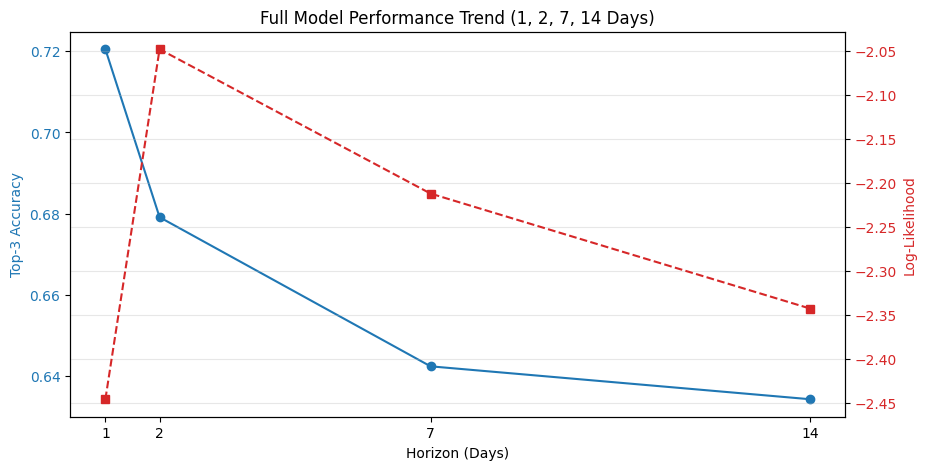

In [17]:
horizons_v2 = [1, 2, 7, 14]
states_v2 = sorted(train_df_v2["state"].unique())
state_to_idx_v2 = {s: i for i, s in enumerate(states_v2)}

P_full_mat_v2 = full_matrix_v2.values  

full_metrics_v2 = {"Horizon": [], "Log-Likelihood": [], "Top-3 Accuracy": []}

for n in horizons_v2:
    P_n_v2 = np.linalg.matrix_power(P_full_mat_v2, n)
    
    log_liks = []
    top_3_correct = 0
    total_samples = 0
    
    for i in range(len(test_df_v2) - n):
        curr_state = test_df_v2.iloc[i]["state"]
        true_future = test_df_v2.iloc[i + n]["state"]
        
        curr_idx = state_to_idx_v2[curr_state]
        futu_idx = state_to_idx_v2[true_future]
        
        prob = P_n_v2[curr_idx, futu_idx]
        log_liks.append(np.log(prob + 1e-12))
        
        if futu_idx in np.argsort(P_n_v2[curr_idx])[-3:]:
            top_3_correct += 1
        
        total_samples += 1
    
    full_metrics_v2["Horizon"].append(n)
    full_metrics_v2["Log-Likelihood"].append(np.mean(log_liks))
    full_metrics_v2["Top-3 Accuracy"].append(top_3_correct / total_samples)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Horizon (Days)')
ax1.set_ylabel('Top-3 Accuracy', color='tab:blue')
ax1.plot(full_metrics_v2["Horizon"], full_metrics_v2["Top-3 Accuracy"], marker='o', color='tab:blue', label='Accuracy')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Log-Likelihood', color='tab:red')
ax2.plot(full_metrics_v2["Horizon"], full_metrics_v2["Log-Likelihood"], marker='s', color='tab:red', linestyle='--', label='Log-Likelihood')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Full Model Performance Trend (1, 2, 7, 14 Days)')
plt.xticks(horizons_v2)
plt.grid(True, alpha=0.3)
plt.show()

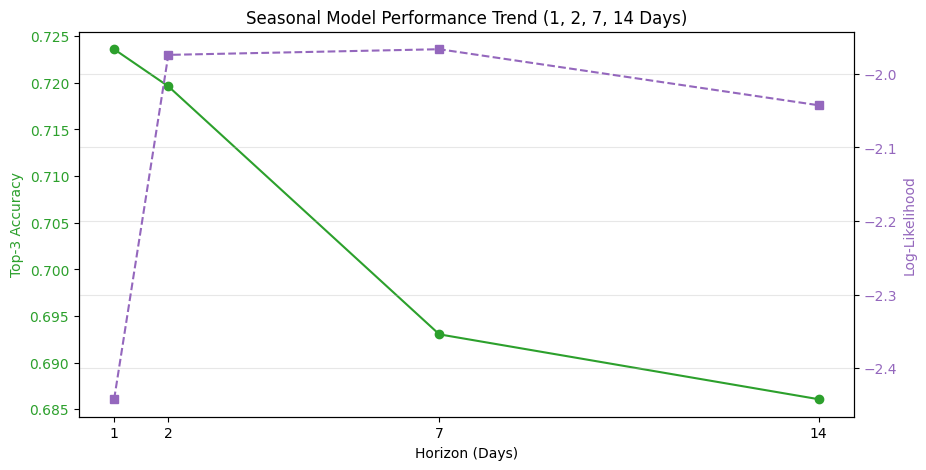

In [18]:
seasonal_metrics_v2 = {"Horizon": [], "Log-Likelihood": [], "Top-3 Accuracy": []}

for n in horizons_v2:
    log_liks = []
    top_3_correct = 0
    total_samples = 0
    
    for i in range(len(test_df_v2) - n):
        season = test_df_v2.iloc[i]["season"]
        curr_state = test_df_v2.iloc[i]["state"]
        true_future = test_df_v2.iloc[i + n]["state"]
        
        curr_idx = state_to_idx_v2[curr_state]
        futu_idx = state_to_idx_v2[true_future]
        
        P_season_v2 = season_matrices_v2[season].values
        P_n_v2 = np.linalg.matrix_power(P_season_v2, n)
        
        prob = P_n_v2[curr_idx, futu_idx]
        log_liks.append(np.log(prob + 1e-12))
        
        if futu_idx in np.argsort(P_n_v2[curr_idx])[-3:]:
            top_3_correct += 1
        total_samples += 1
        
    seasonal_metrics_v2["Horizon"].append(n)
    seasonal_metrics_v2["Log-Likelihood"].append(np.mean(log_liks))
    seasonal_metrics_v2["Top-3 Accuracy"].append(top_3_correct / total_samples)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Horizon (Days)')
ax1.set_ylabel('Top-3 Accuracy', color='tab:green')
ax1.plot(seasonal_metrics_v2["Horizon"], seasonal_metrics_v2["Top-3 Accuracy"], marker='o', color='tab:green', label='Accuracy')
ax1.tick_params(axis='y', labelcolor='tab:green')

ax2 = ax1.twinx()
ax2.set_ylabel('Log-Likelihood', color='tab:purple')
ax2.plot(seasonal_metrics_v2["Horizon"], seasonal_metrics_v2["Log-Likelihood"], marker='s', color='tab:purple', linestyle='--', label='Log-Likelihood')
ax2.tick_params(axis='y', labelcolor='tab:purple')

plt.title('Seasonal Model Performance Trend (1, 2, 7, 14 Days)')
plt.xticks(horizons_v2)
plt.grid(True, alpha=0.3)
plt.show()

# Second Order Chain

In [19]:
train_df_v2 = train_df_v2.sort_values("DATE").reset_index(drop=True)

train_df_v2["prev_state"] = train_df_v2["state"].shift(1)
train_df_v2["state_2nd"] = train_df_v2["prev_state"] + "|" + train_df_v2["state"]
train_df_v2["next_state_2nd"] = train_df_v2["state"].shift(-1)

train_df_v2 = train_df_v2.dropna(subset=["prev_state", "next_state_2nd"])

In [20]:
states_2nd = sorted(train_df_v2["state_2nd"].unique())
state_to_idx_2nd = {s: i for i, s in enumerate(states_2nd)}

matrix_2nd = pd.crosstab(
    train_df_v2["state_2nd"],
    train_df_v2["next_state_2nd"],
    normalize="index"
)

In [21]:
prev = train_df_v2.iloc[-1]["prev_state"]  
curr = train_df_v2.iloc[-1]["state"]       

forecast_2nd = []
states_1st = sorted(train_df_v2["state"].unique())  

for i in range(len(test_df_v2)):
    compound = f"{prev}|{curr}"
    
    if compound in matrix_2nd.index:
        probs = matrix_2nd.loc[compound].reindex(states_1st, fill_value=0).values
    else:
        probs = np.ones(len(states_1st)) / len(states_1st)
    
    probs = probs / probs.sum()
    next_state = np.random.choice(states_1st, p=probs)
    forecast_2nd.append(next_state)
    
    prev = curr
    curr = test_df_v2.iloc[i]["state"]  

test_df_v2["pred_state_2nd"] = forecast_2nd

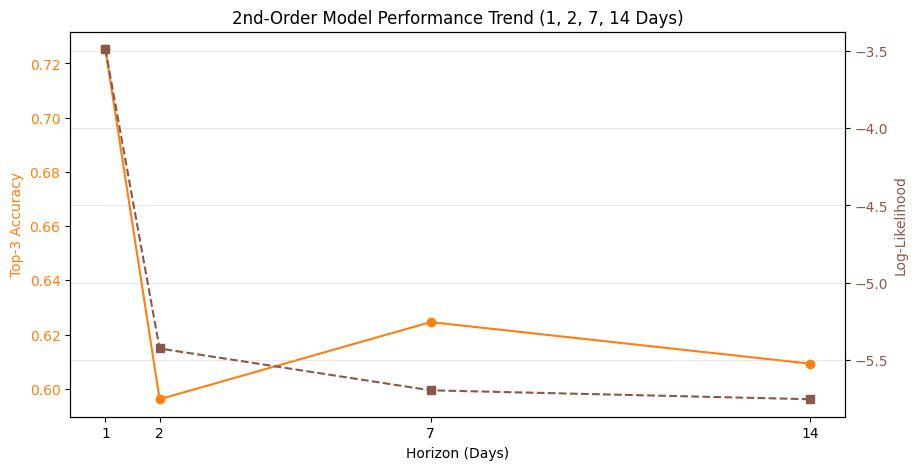

In [22]:
metrics_2nd = {"Horizon": [], "Log-Likelihood": [], "Top-3 Accuracy": []}

P_2nd = matrix_2nd.reindex(columns=states_1st, fill_value=0).values

for n in horizons_v2:
    log_liks = []
    top_3_correct = 0
    total = 0

    for i in range(len(test_df_v2) - n):
        prev = train_df_v2.iloc[-1]["state"] if i == 0 else test_df_v2.iloc[i-1]["state"]
        curr = test_df_v2.iloc[i]["state"]
        compound = f"{prev}|{curr}"
        true_future = test_df_v2.iloc[i + n]["state"]

        if compound not in matrix_2nd.index:
            continue

        row_idx = list(matrix_2nd.index).index(compound)
        fut_idx = states_1st.index(true_future)

        prob = P_2nd[row_idx, fut_idx]
        log_liks.append(np.log(prob + 1e-12))

        if fut_idx in np.argsort(P_2nd[row_idx])[-3:]:
            top_3_correct += 1
        total += 1

    metrics_2nd["Horizon"].append(n)
    metrics_2nd["Log-Likelihood"].append(np.mean(log_liks))
    metrics_2nd["Top-3 Accuracy"].append(top_3_correct / total)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Horizon (Days)')
ax1.set_ylabel('Top-3 Accuracy', color='tab:orange')
ax1.plot(metrics_2nd["Horizon"], metrics_2nd["Top-3 Accuracy"], marker='o', color='tab:orange', label='Accuracy')
ax1.tick_params(axis='y', labelcolor='tab:orange')

ax2 = ax1.twinx()
ax2.set_ylabel('Log-Likelihood', color='tab:brown')
ax2.plot(metrics_2nd["Horizon"], metrics_2nd["Log-Likelihood"], marker='s', color='tab:brown', linestyle='--', label='Log-Likelihood')
ax2.tick_params(axis='y', labelcolor='tab:brown')

plt.title('2nd-Order Model Performance Trend (1, 2, 7, 14 Days)')
plt.xticks(horizons_v2)
plt.grid(True, alpha=0.3)
plt.show()

# Extreme States

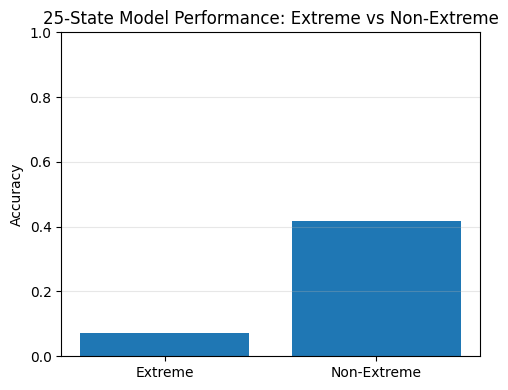

In [26]:
extreme = test_df_v2["state"].str.contains(
    "Heavy|Snow|Ice|Thunder|Hail|Storm|Convective|Winter|Fog|Wind|Sleet",
    regex=True
)

acc_25_ext = (test_df_v2.loc[extreme, "pred_state"] == test_df_v2.loc[extreme, "state"]).mean()

acc_25_non = (test_df_v2.loc[~extreme, "pred_state"] == test_df_v2.loc[~extreme, "state"]).mean()

labels = ["Extreme", "Non-Extreme"]
values = [acc_25_ext, acc_25_non]

plt.figure(figsize=(5,4))
plt.bar(labels, values)

plt.ylabel("Accuracy")
plt.title("25-State Model Performance: Extreme vs Non-Extreme")
plt.ylim(0, 1)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()